# 07 — Out-of-sample: does the pump-fade hold in 2025?

Everything so far was 2024 H2 (in-sample). Here we re-run the SAME rule on a
completely different period — **2025-01 .. 2025-09, 154 symbols** — with no
re-tuning. Rule: short full size at the pump trigger, 3% stop, exit +240m.

If the edge survives untouched here, it's much more likely real.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

PRE, EXIT = 60, 240
def load_P(fname):
    paths = np.load(fname)
    return (1.0 + paths)[:, PRE:PRE + EXIT + 1]

P24 = load_P('_out/pump_paths.npy')          # 2024 H2 (in-sample)
P25 = load_P('_out/pump_paths_2025.npy')     # 2025 (out-of-sample)
ts25 = pd.to_datetime(np.load('_out/pump_ts_2025.npy'))
print(f'2024 events: {P24.shape[0]}   |   2025 events: {P25.shape[0]}')

2024 events: 766   |   2025 events: 2178


In [2]:
def short_pnl(P, stop=None):
    """Full short at trigger; optional stop at +stop above entry; else exit at +EXIT."""
    p0 = P[:, 0]
    exit_p = P[:, -1].copy()
    if stop is not None:
        thr = p0 * (1 + stop)
        hit = P >= thr[:, None]
        hit[:, 0] = False
        for i in range(P.shape[0]):
            w = np.argmax(hit[i])
            if hit[i, w]:
                exit_p[i] = P[i, w]
    return 1.0 - exit_p / p0       # short PnL

def stats(p):
    return (p.mean()*100, np.median(p)*100, (p>0).mean()*100,
            p.std()*100, np.quantile(p, .1)*100, p.mean()/p.std())

HDR = f"{'period / rule':<28}{'n':>6}{'mean':>8}{'median':>8}{'win%':>7}{'std':>8}{'q10':>8}{'m/std':>7}"
def row(name, p):
    m, md, w, sd, q, sh = stats(p)
    print(f"{name:<28}{len(p):>6}{m:>+7.2f}%{md:>+7.2f}%{w:>6.1f}%{sd:>7.2f}%{q:>+7.2f}%{sh:>7.3f}")

print(HDR)
row('2024  no stop',  short_pnl(P24))
row('2024  stop 3%',  short_pnl(P24, 0.03))
print()
row('2025  no stop',  short_pnl(P25))
row('2025  stop 3%',  short_pnl(P25, 0.03))

period / rule                    n    mean  median   win%     std     q10  m/std
2024  no stop                  766  +1.47%  +1.87%  64.5%   5.92%  -6.42%  0.248
2024  stop 3%                  766  +1.39%  +1.11%  56.5%   4.86%  -3.76%  0.286

2025  no stop                 2178  +1.78%  +2.09%  65.7%   5.94%  -5.75%  0.300
2025  stop 3%                 2178  +1.67%  +1.34%  56.6%   5.16%  -3.53%  0.324


## Average path: same shape in 2025?

[saved] notebooks\_out\07_path_2024_vs_2025.png


WindowsPath('C:/projects/researchlab/notebooks/_out/07_path_2024_vs_2025.png')

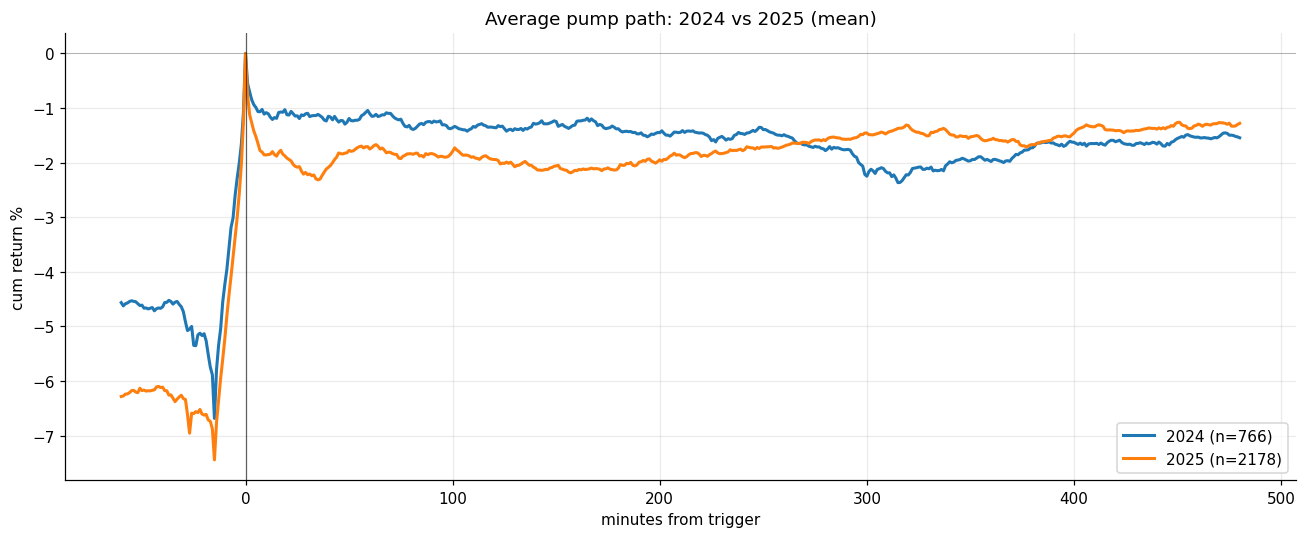

In [3]:
full24 = (1.0 + np.load('_out/pump_paths.npy'))
full25 = (1.0 + np.load('_out/pump_paths_2025.npy'))
offs = np.arange(-PRE, full24.shape[1] - PRE)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(offs, (full24.mean(0) - 1)*100, lw=2, label=f'2024 (n={full24.shape[0]})')
ax.plot(offs, (full25.mean(0) - 1)*100, lw=2, label=f'2025 (n={full25.shape[0]})')
ax.axvline(0, color='k', lw=0.8, alpha=0.6); ax.axhline(0, color='k', lw=0.5, alpha=0.3)
ax.set_xlabel('minutes from trigger'); ax.set_ylabel('cum return %')
ax.set_title('Average pump path: 2024 vs 2025 (mean)')
ax.legend(); show('07_path_2024_vs_2025')

## Annual return 2025 (idealized)

Each pump signal = one short trade (rule: stop 3%, exit +240m). Cumulative sum
of per-trade PnL over the year, **gross** and **net of ~0.15% round-trip cost**.

Caveat: this risks 1 unit per trade and ignores that trades overlap in time
(no concurrency/capital cap). It's a clean read on edge-per-trade and totals,
not a finished portfolio.

[saved] notebooks\_out\07_equity_2025.png
trades: 2178
mean/trade  gross +1.669%   net +1.519%
win% gross 56.6   net 55.8
sum of per-trade PnL  gross +3635.0%   net +3308.3%  (9 months)


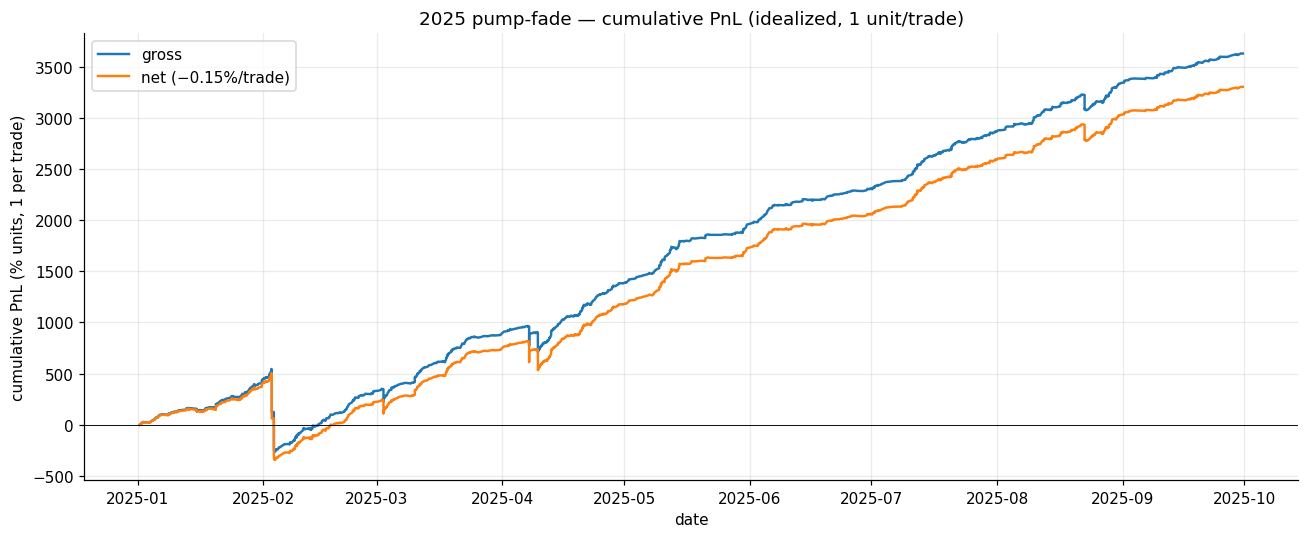

In [4]:
COST = 0.0015     # round-trip cost estimate (taker both sides + slippage), alts
pnl = short_pnl(P25, 0.03)
order = np.argsort(ts25.values)
t_sorted = ts25.values[order]
gross = pnl[order]
net = gross - COST

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_sorted, np.cumsum(gross)*100, lw=1.6, label='gross')
ax.plot(t_sorted, np.cumsum(net)*100, lw=1.6, label=f'net (−{COST*100:.2f}%/trade)')
ax.axhline(0, color='k', lw=0.6)
ax.set_ylabel('cumulative PnL (% units, 1 per trade)'); ax.set_xlabel('date')
ax.set_title('2025 pump-fade — cumulative PnL (idealized, 1 unit/trade)')
ax.legend(); show('07_equity_2025')

print(f'trades: {len(pnl)}')
print(f'mean/trade  gross {gross.mean()*100:+.3f}%   net {net.mean()*100:+.3f}%')
print(f'win% gross {(gross>0).mean()*100:.1f}   net {(net>0).mean()*100:.1f}')
print(f'sum of per-trade PnL  gross {gross.sum()*100:+.1f}%   net {net.sum()*100:+.1f}%  (9 months)')

In [5]:
# monthly consistency: mean net PnL/trade and trade count
m = pd.DataFrame({'pnl': net, 't': pd.to_datetime(t_sorted)})
m['month'] = m['t'].dt.to_period('M')
g = m.groupby('month')['pnl'].agg(['mean', 'count', 'sum'])
g['mean'] *= 100; g['sum'] *= 100
print('monthly NET (per-trade mean %, count, summed %):')
print(g.round(2).to_string())
print(f"\nprofitable months: {(g['mean']>0).sum()} / {len(g)}")

monthly NET (per-trade mean %, count, summed %):
         mean  count     sum
month                       
2025-01  1.59    253  403.39
2025-02 -0.40    458 -182.70
2025-03  1.98    260  514.07
2025-04  1.08    407  440.63
2025-05  3.44    161  554.62
2025-06  2.96    112  331.18
2025-07  2.86    187  534.36
2025-08  1.87    236  441.62
2025-09  2.61    104  271.14

profitable months: 8 / 9
